In [1]:
!pip install -q datasets librosa soundfile pyarrow tqdm

In [2]:
from pathlib import Path

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

## Constants
`snr` (signal-to-noise ratio) and `utmos` (predicted MOS score). We filter for all samples where `snr ≥ 10` and `utmos ≥ 2.5` is true

In [4]:
SNR_MIN = 10.0
UTMOS_MIN = 2.5
MIN_SAMPLES_PER_CLASS = 100
TRAIN_PARQUET = Path('globe_v3_train_no_audio.parquet')

## 1. Load Metadata

Read the GLOBE_V3 train split from a local parquet file (`globe_v3_train_no_audio.parquet`, ~705k rows). The audio column was excluded due to the size of the data

In [5]:
df_train_raw = pd.read_parquet(TRAIN_PARQUET)
print(f"Loaded {len(df_train_raw):,} rows from {TRAIN_PARQUET}")
print(f"Columns: {df_train_raw.columns.tolist()}")

Loaded 704,750 rows from globe_v3_train_no_audio.parquet
Columns: ['snr', 'whisper_transcription_large_v3', 'utmos', 'wer', 'cer', 'predicted_gender', 'predicted_accent', 'predicted_age', 'common_voice_path', 'common_voice_sentence_id', 'common_voice_sentence', 'common_voice_age', 'common_voice_gender', 'common_voice_accents']


## 2. EDA

In [6]:
df_train_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 704750 entries, 0 to 704749
Data columns (total 14 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   snr                             704750 non-null  float32
 1   whisper_transcription_large_v3  704750 non-null  str    
 2   utmos                           704750 non-null  float32
 3   wer                             704750 non-null  float32
 4   cer                             704750 non-null  float32
 5   predicted_gender                704750 non-null  str    
 6   predicted_accent                704750 non-null  str    
 7   predicted_age                   704750 non-null  str    
 8   common_voice_path               704750 non-null  str    
 9   common_voice_sentence_id        704750 non-null  str    
 10  common_voice_sentence           704750 non-null  str    
 11  common_voice_age                704750 non-null  str    
 12  common_voice_gender        

In [7]:
df_train_raw.head()

,snr,whisper_transcription_large_v3,utmos,wer,cer,predicted_gender,predicted_accent,predicted_age,common_voice_path,common_voice_sentence_id,common_voice_sentence,common_voice_age,common_voice_gender,common_voice_accents
0,100.0,This was formerly the distance for college ba...,3.754178,0.0,0.0,female,United States English,fourties,common_voice_en_19718756.mp3,20c2597634219667944e1557400f44178bd044114fba1f...,This was formerly the distance for college bas...,nan,nan,nan
1,100.0,Different fare plans exist.,3.920858,0.0,0.0,female,United States English,thirties,common_voice_en_19718822.mp3,20e7ab78af32f3a5fb726c0ff90481fdd1e1e594c26a0a...,Different fare plans exist.,nan,nan,nan
2,100.0,They live on the southwest Oregon Pacific coast.,3.552613,0.0,0.0,female,United States English,thirties,common_voice_en_19718762.mp3,20e74f9da374844a432002db9ef62a845d8a39dbdac6cc...,They live on the southwest Oregon Pacific coast.,nan,nan,nan
3,100.0,He ran the second leg of the race.,3.940485,0.0,0.0,female,England English,fourties,common_voice_en_19718750.mp3,20c6fc0a017c9d906cf51bc3a4076758fcc42057eb8426...,He ran the second leg of the race.,nan,nan,nan
4,100.0,Bates did other research.,3.320445,0.0,0.0,female,England English,twenties,common_voice_en_19718823.mp3,20ddef0eddb49b6cd58a841538e9b22d3cb348c243f0ce...,Bates did other research.,nan,nan,nan


In [8]:
df_train_raw.describe()

,snr,utmos,wer,cer
count,704750.000000,704750.000000,704750.0,704750.0
mean,87.393326,3.269082,0.0,0.0
std,24.219185,0.675409,0.0,0.0
min,-20.000000,1.221736,0.0,0.0
25%,100.000000,2.856312,0.0,0.0
50%,100.000000,3.367598,0.0,0.0
75%,100.000000,3.772802,0.0,0.0
max,100.000000,4.563447,0.0,0.0


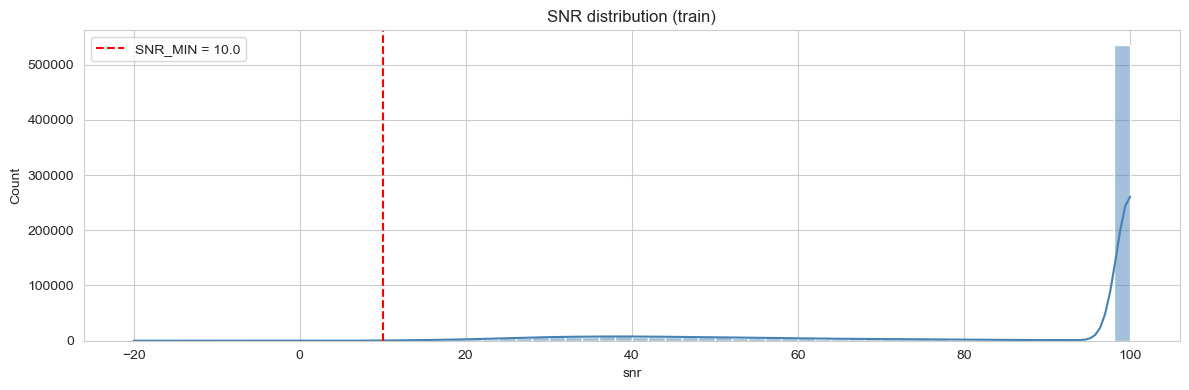

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(df_train_raw, x='snr', kde=True, ax=ax, bins=60, color='steelblue')
ax.axvline(SNR_MIN, color='red', linestyle='--', label=f'SNR_MIN = {SNR_MIN}')
ax.set_title('SNR distribution (train)')
ax.legend()
plt.tight_layout()
plt.show()

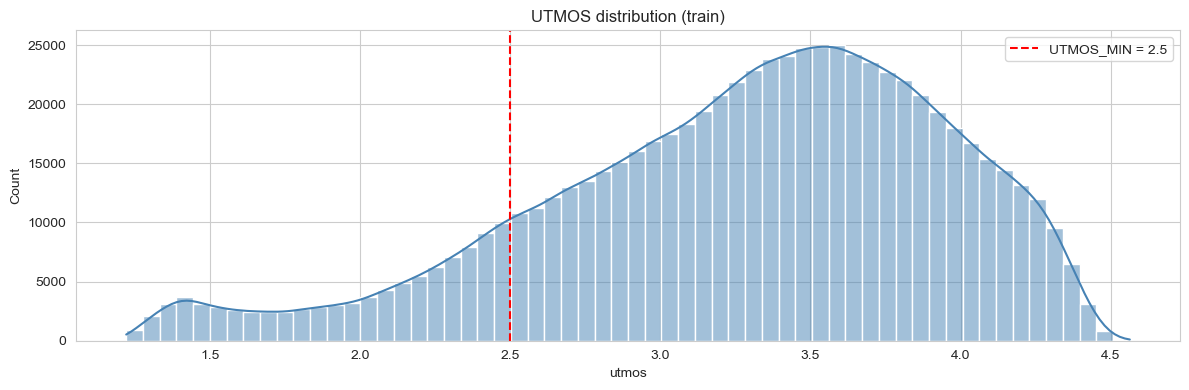

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(df_train_raw, x='utmos', kde=True, ax=ax, bins=60, color='steelblue')
ax.axvline(UTMOS_MIN, color='red', linestyle='--', label=f'UTMOS_MIN = {UTMOS_MIN}')
ax.set_title('UTMOS distribution (train)')
ax.legend()
plt.tight_layout()
plt.show()

### WER & CER

`wer` (word error rate) and `cer` (character error rate) is pre-filtered to `wer == cer == 0`

In [11]:
print('--- describe ---')
print(df_train_raw[['wer', 'cer']].describe())
print()
print('Non-zero wer:', (df_train_raw['wer'] > 0).sum())
print('Non-zero cer:', (df_train_raw['cer'] > 0).sum())

--- describe ---
            wer       cer
count  704750.0  704750.0
mean        0.0       0.0
std         0.0       0.0
min         0.0       0.0
25%         0.0       0.0
50%         0.0       0.0
75%         0.0       0.0
max         0.0       0.0

Non-zero wer: 0
Non-zero cer: 0


In [12]:
# Rows with any transcription error — check quality signal overlap
err_mask = (df_train_raw['wer'] > 0) | (df_train_raw['cer'] > 0)
df_err = df_train_raw[err_mask][['wer', 'cer', 'snr', 'utmos', 'predicted_accent']]
print(f'Rows with wer > 0 or cer > 0: {len(df_err):,}')

if len(df_err):
    print()
    print(df_err.describe())
    print()
    # Correlation between transcription error and quality metrics
    corr = df_train_raw[['wer', 'cer', 'snr', 'utmos']].corr()
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
    ax.set_title('Correlation: WER / CER vs quality metrics')
    plt.tight_layout()
    plt.show()

Rows with wer > 0 or cer > 0: 0


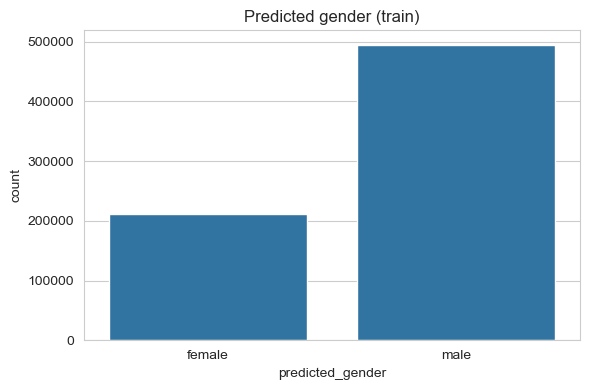

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_train_raw, x='predicted_gender', ax=ax)
ax.set_title('Predicted gender (train)')
plt.tight_layout()
plt.show()

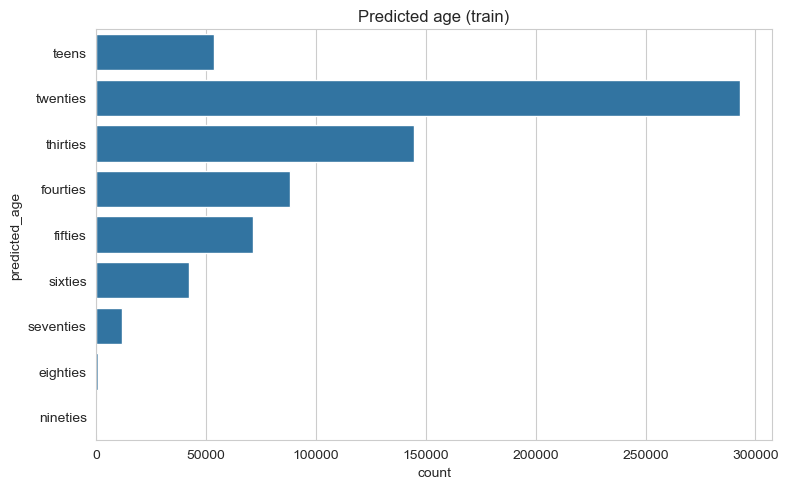

In [14]:
AGE_ORDER = ['teens', 'twenties', 'thirties', 'fourties', 'fifties',
             'sixties', 'seventies', 'eighties', 'nineties']
present_ages = [a for a in AGE_ORDER if a in df_train_raw['predicted_age'].unique()]

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df_train_raw, y='predicted_age', order=present_ages, ax=ax)
ax.set_title('Predicted age (train)')
plt.tight_layout()
plt.show()

### Accent class distribution

The raw corpus has 251 unique `predicted_accent` labels. However showing the top 25 predicted accents presents the steep drop off after the top 3 accents. The table below the next plot shows the % of data as you increase the samples per accent bin

Unique accents in raw train: 251


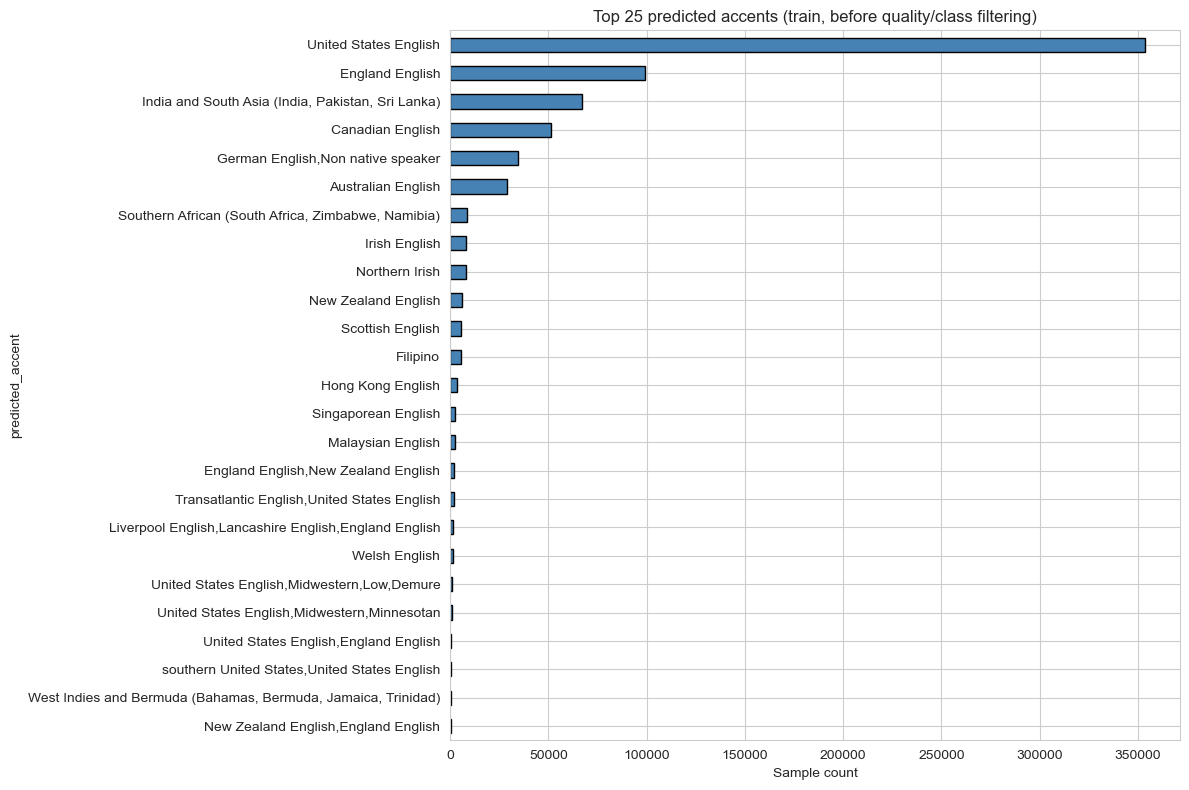

In [15]:
accent_counts = df_train_raw['predicted_accent'].value_counts()
print(f"Unique accents in raw train: {len(accent_counts)}")

fig, ax = plt.subplots(figsize=(12, 8))
accent_counts.head(25).plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.invert_yaxis()
ax.set_xlabel('Sample count')
ax.set_title('Top 25 predicted accents (train, before quality/class filtering)')
plt.tight_layout()
plt.show()

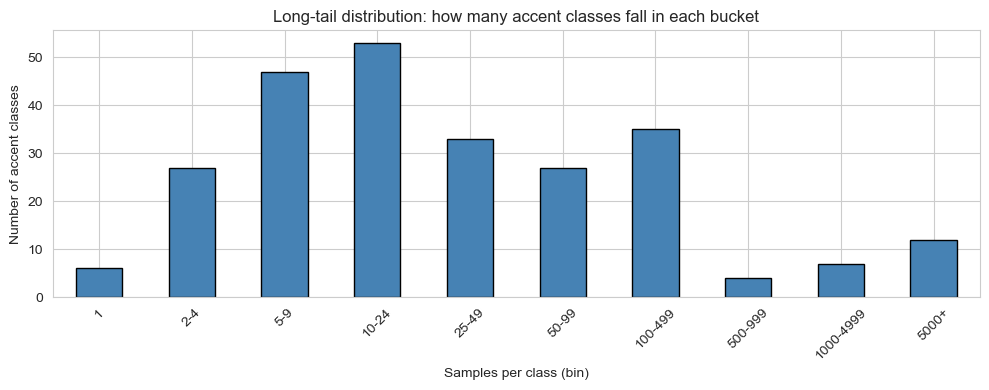

In [16]:
bins = [1, 2, 5, 10, 25, 50, 100, 500, 1000, 5000, 10**7]
labels = ['1', '2-4', '5-9', '10-24', '25-49', '50-99',
          '100-499', '500-999', '1000-4999', '5000+']
binned = pd.cut(accent_counts, bins=bins, labels=labels, right=False)

fig, ax = plt.subplots(figsize=(10, 4))
binned.value_counts().reindex(labels).plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_ylabel('Number of accent classes')
ax.set_xlabel('Samples per class (bin)')
ax.set_title('Long-tail distribution: how many accent classes fall in each bucket')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
thresholds = [10, 25, 50, 100, 200, 500, 1000]
rows = []
for t in thresholds:
    filt = accent_counts[accent_counts >= t]
    rows.append({
        'min_samples': t,
        'num_classes': len(filt),
        'total_samples': int(filt.sum()),
        'pct_of_train': round(100 * filt.sum() / len(df_train_raw), 1),
    })
pd.DataFrame(rows)

,min_samples,num_classes,total_samples,pct_of_train
0,10,171,704341,99.9
1,25,118,703489,99.8
2,50,85,702368,99.7
3,100,58,700447,99.4
4,200,36,697483,99.0
5,500,23,694088,98.5
6,1000,19,691037,98.1


## 3. Filtered Class Set

We apply quality thresholds (`snr ≥ 10`, `utmos ≥ 2.5`) and keep only accent classes with ≥ 100 surviving samples to create a defined set of classes with sufficient representation for analysis

In [18]:
def quality_gate(df):
    n_before = len(df)
    df_ = df[(df['snr'] >= SNR_MIN) & (df['utmos'] >= UTMOS_MIN)].copy()
    n_after = len(df_)
    print(f"  {n_before:>7,} → {n_after:>7,}  ({100 * n_after / n_before:.1f}% retained)")
    return df_

print("Applying quality gate:")
print(" train:", end=" "); df_train_q = quality_gate(df_train_raw)

Applying quality gate:
 train:   704,750 → 609,046  (86.4% retained)


In [19]:
train_accent_counts_q = df_train_q['predicted_accent'].value_counts()
keep_accents = sorted(train_accent_counts_q[train_accent_counts_q >= MIN_SAMPLES_PER_CLASS].index.tolist())
print(f"Classes with ≥ {MIN_SAMPLES_PER_CLASS} train samples after quality gate: {len(keep_accents)}")
print(f"Examples: {keep_accents[:8]}")

Classes with ≥ 100 train samples after quality gate: 52
Examples: ['Academic southern English,England English', 'Australian English', 'Austrian', 'Canadian English', 'Dutch', 'Dutch English', 'East African Khoja', 'Eastern European English']


In [20]:
df_train_f = df_train_q[df_train_q['predicted_accent'].isin(keep_accents)].copy()

print(f"After class filter — train: {len(df_train_f):,}")

After class filter — train: 604,895


## 4. Demographic Balance by Accent Class

Cross-tabulated `predicted_gender` and `predicted_age` against `predicted_accent` for the quality-filtered, class-filtered train data

/var/folders/fq/lbwkp8kd5tb9sr0tkcqx8dhh0000gn/T/ipykernel_45649/3040807488.py:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


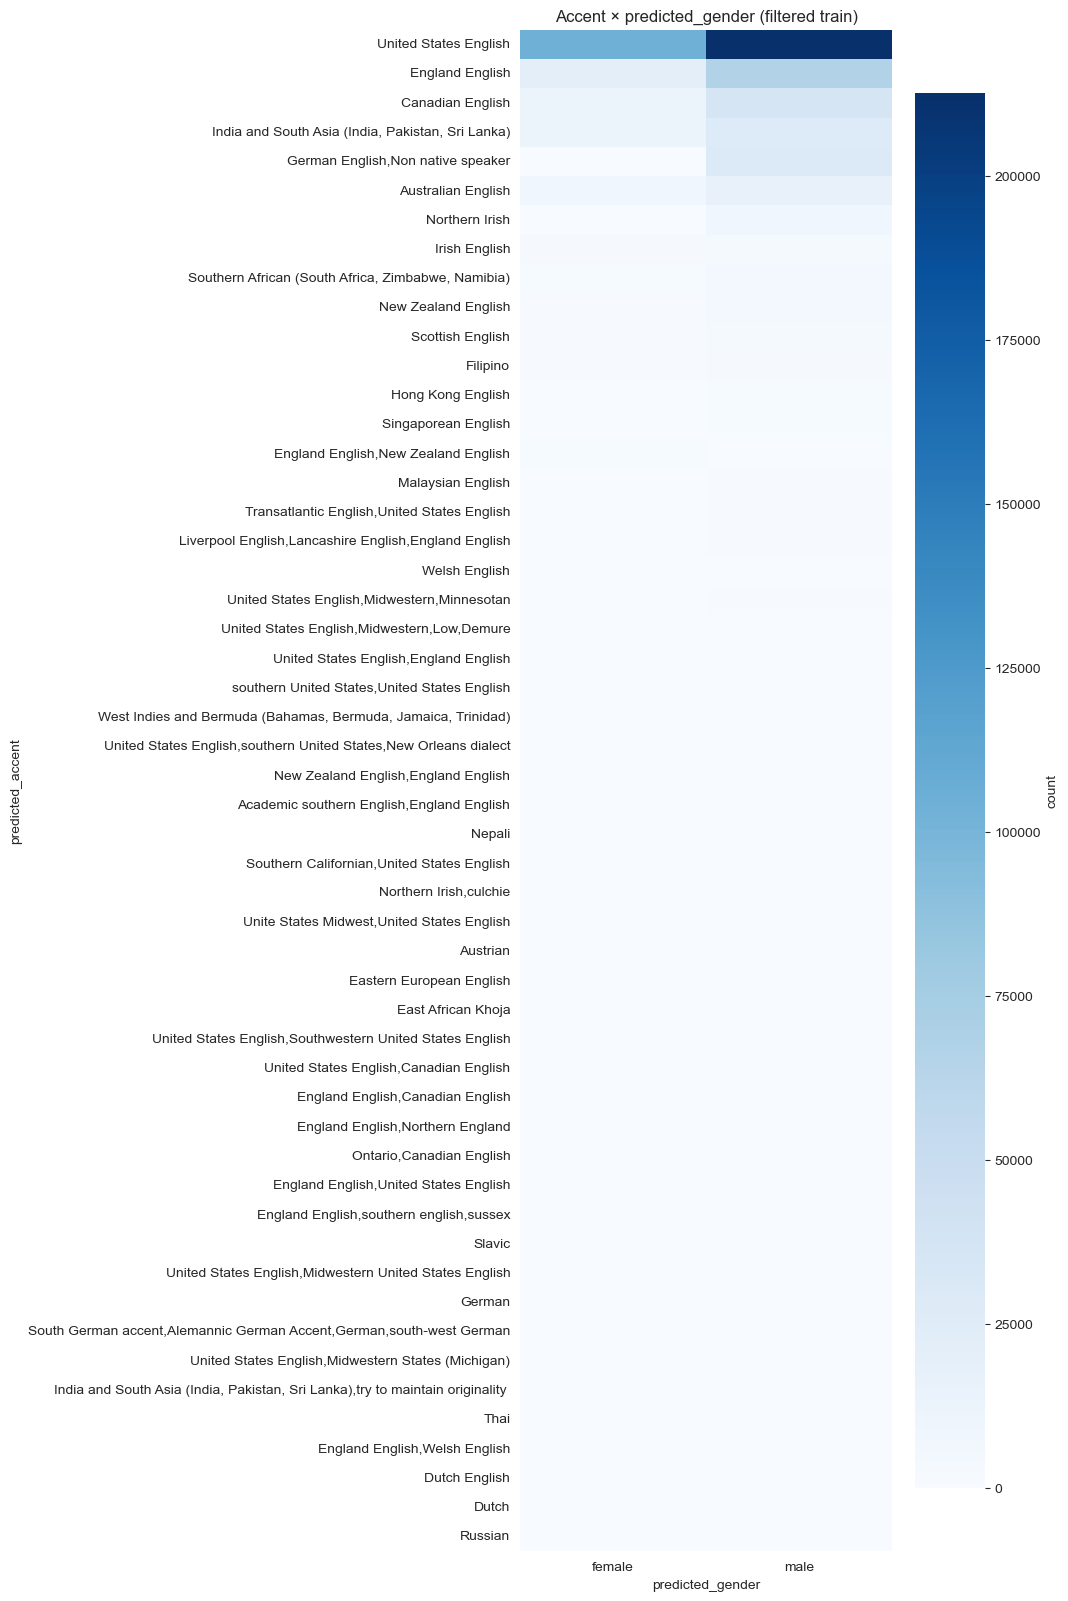

In [21]:
ct_gender = pd.crosstab(df_train_f['predicted_accent'], df_train_f['predicted_gender'])
ct_gender = ct_gender.loc[ct_gender.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(6, max(8, len(ct_gender) * 0.38)))
sns.heatmap(ct_gender, annot=False, cmap='Blues', ax=ax, cbar_kws={'label': 'count'})
ax.set_title('Accent × predicted_gender (filtered train)')
plt.tight_layout()
plt.show()

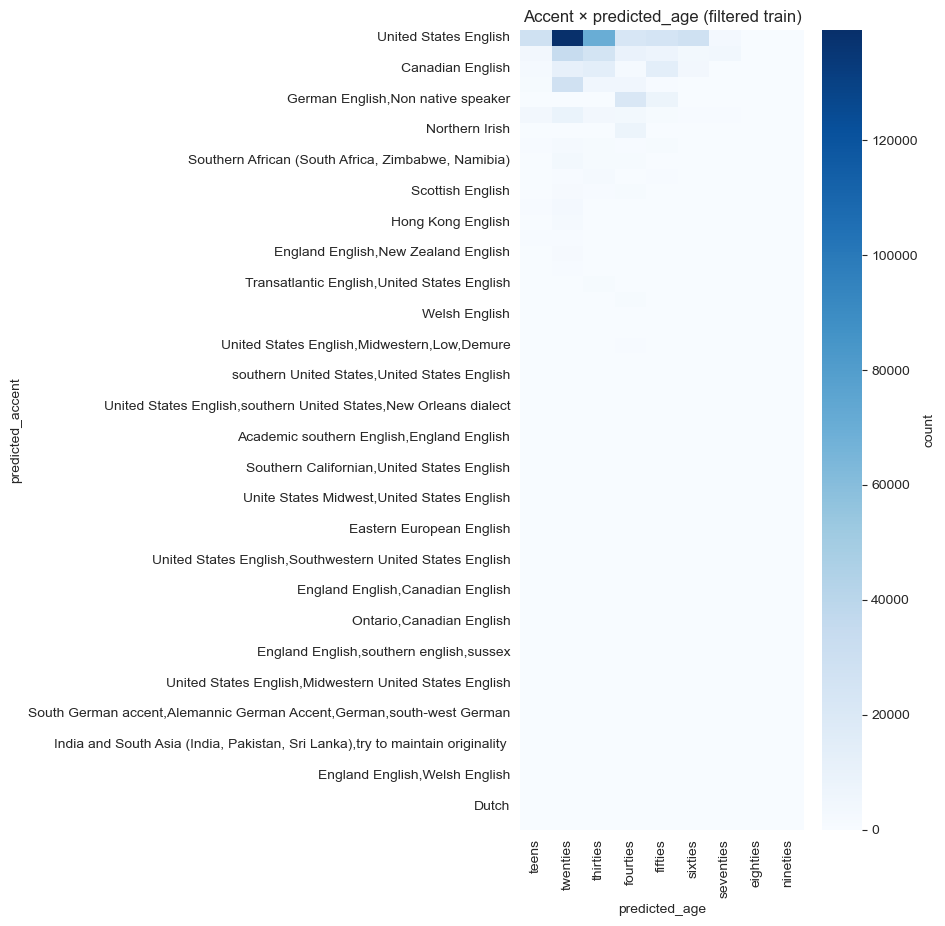

In [22]:
ct_age = pd.crosstab(df_train_f['predicted_accent'], df_train_f['predicted_age'])
ct_age = ct_age[[a for a in AGE_ORDER if a in ct_age.columns]]
ct_age = ct_age.loc[ct_age.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9, max(8, len(ct_age) * 0.18)))
sns.heatmap(ct_age, annot=False, cmap='Blues', ax=ax, cbar_kws={'label': 'count'})
ax.set_title('Accent × predicted_age (filtered train)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.tight_layout()
plt.show()